In [1]:
import sys
from pathlib import Path

import ee
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent

# Allow imports from the project
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: d:\AgroMet


In [2]:
ee.Initialize(project="alien-cedar-483108-h3")

print("Earth Engine initialized")

Earth Engine initialized


In [3]:
station_df = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "maha_temp_raw.csv"
)

print("Shape:", station_df.shape)
print(station_df.columns.tolist())

Shape: (2831139, 10)
['_id', 'SlNo', 'Station', 'Agency', 'State', 'District', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Air Temperature Telemetry Hourly (AoC)']


In [4]:
test_stations = {
    "Sarud": (16.89777778, 74.04333333),
    "Patryachiwadi": (16.61611111, 73.99166667),
    "Chandgad_1": (15.93666667, 74.17694489),
    "Rukadi": (16.72000000, 74.35555600),
}

station_test = station_df[
    station_df["Station"].isin(test_stations.keys())
].copy()

print("Shape:", station_test.shape)
print("\nStations:")
print(station_test["Station"].value_counts())

Shape: (213881, 10)

Stations:
Station
Sarud            79019
Patryachiwadi    64669
Chandgad_1       52682
Rukadi           17511
Name: count, dtype: int64


In [5]:
station_test["time"] = pd.to_datetime(
    station_test["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
).dt.tz_localize("Asia/Kolkata")

station_test["time_utc"] = station_test["time"].dt.tz_convert("UTC")

station_test["hour_utc"] = station_test["time_utc"].dt.floor("h")

hourly_station_all = (
    station_test
    .groupby(["Station", "hour_utc"])["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

print("Hourly dataframe shape:", hourly_station_all.shape)
print("\nDuplicate station-hours:",
      hourly_station_all.duplicated(["Station", "hour_utc"]).sum())

hourly_station_all.head()

Hourly dataframe shape: (56010, 3)

Duplicate station-hours: 0


,Station,hour_utc,Air Temperature Telemetry Hourly (AoC)
0,Chandgad_1,2022-02-12 08:00:00+00:00,29.700
1,Chandgad_1,2022-02-12 09:00:00+00:00,29.550
2,Chandgad_1,2022-02-12 10:00:00+00:00,29.675
3,Chandgad_1,2022-02-12 11:00:00+00:00,29.575
4,Chandgad_1,2022-02-12 12:00:00+00:00,25.525


In [6]:
start_time = pd.Timestamp("2023-07-14 18:00:00", tz="UTC")
end_time = pd.Timestamp("2023-07-21 19:00:00", tz="UTC")

validation_stations = hourly_station_all[
    (hourly_station_all["hour_utc"] >= start_time) &
    (hourly_station_all["hour_utc"] <= end_time)
].copy()

print("Shape:", validation_stations.shape)
print("\nObservations per station:")
print(validation_stations["Station"].value_counts())

Shape: (563, 3)

Observations per station:
Station
Sarud            170
Patryachiwadi    132
Rukadi           132
Chandgad_1       129
Name: count, dtype: int64


In [7]:
validation_stations.groupby("Station")[
    "Air Temperature Telemetry Hourly (AoC)"
].agg(["count", "min", "max", "mean"])

,count,min,max,mean
Station,,,,
Chandgad_1,129,20.850,24.70,22.326550
Patryachiwadi,132,20.275,23.60,21.453346
Rukadi,132,21.500,27.60,23.590152
Sarud,170,21.825,26.75,23.448824


In [8]:
from engine.deterministic.temperature import downscale_temperature

print(downscale_temperature)

<function downscale_temperature at 0x000001CA0B890A40>


In [9]:
geojson_dir = PROJECT_ROOT / "data" / "cache" / "geojson"

print("GeoJSON directory:", geojson_dir)
print("Maharashtra files:")
print(list(geojson_dir.glob("mh*.geojson")))

GeoJSON directory: d:\AgroMet\data\cache\geojson
Maharashtra files:
[WindowsPath('d:/AgroMet/data/cache/geojson/mh1.geojson'), WindowsPath('d:/AgroMet/data/cache/geojson/mh2.geojson')]


In [10]:
import geopandas as gpd

print("GeoPandas version:", gpd.__version__)

GeoPandas version: 1.1.4


In [11]:
import requests

api_url = "https://api.github.com/repos/datameet/indian_village_boundaries/contents"

response = requests.get(api_url)

print("Status:", response.status_code)

for item in response.json():
    print(item["name"], item["type"])

Status: 200
CONTRIBUTING.md file
LICENSE file
README.md file
br dir
docs dir
ga dir
gj dir
ka dir
kl dir
mh dir
or dir
rj dir
sk dir
website dir


In [12]:
mh_api_url = "https://api.github.com/repos/datameet/indian_village_boundaries/contents/mh"

response = requests.get(mh_api_url)

print("Status:", response.status_code)

for item in response.json():
    print(item["name"], item["type"])

Status: 200
mh.csv file
mh1.geojson file
mh2.geojson file


In [13]:
geojson_dir = PROJECT_ROOT / "data" / "cache" / "geojson"
geojson_dir.mkdir(parents=True, exist_ok=True)

for filename in ["mh1.geojson", "mh2.geojson"]:
    url = f"https://raw.githubusercontent.com/datameet/indian_village_boundaries/master/mh/{filename}"
    
    response = requests.get(url)
    response.raise_for_status()
    
    output_path = geojson_dir / filename
    output_path.write_bytes(response.content)
    
    print(f"Saved: {output_path}")

Saved: d:\AgroMet\data\cache\geojson\mh1.geojson
Saved: d:\AgroMet\data\cache\geojson\mh2.geojson


In [14]:
mh1 = gpd.read_file(geojson_dir / "mh1.geojson")
mh2 = gpd.read_file(geojson_dir / "mh2.geojson")

print("mh1:", mh1.shape)
print("mh2:", mh2.shape)

print("\nColumns:")
print(mh1.columns.tolist())

print("\nCRS:")
print(mh1.crs)

mh1: (25000, 7)
mh2: (23926, 7)

Columns:
['SUB_DIST', 'DISTRICT', 'STATE', 'TYPE', 'NAME', 'CEN_2001', 'geometry']

CRS:
EPSG:4326


In [15]:
mh = pd.concat([mh1, mh2], ignore_index=True)

print("Total Maharashtra villages:", len(mh))
print(mh["STATE"].unique())

Total Maharashtra villages: 48926
<StringArray>
['Maharashtra']
Length: 1, dtype: str


In [16]:
target_names = [
    "Sarud",
    "Patryachiwadi",
    "Chandgad_1",
    "Rukadi"
]

matches = mh[mh["NAME"].isin(target_names)].copy()

print("Matches found:", len(matches))
print(matches[["NAME", "DISTRICT", "SUB_DIST"]].to_string(index=False))

Matches found: 2
  NAME DISTRICT     SUB_DIST
Rukadi Kolhapur Hatkalangale
 Sarud Kolhapur    Shahuwadi


In [17]:
for name in ["Patryachiwadi", "Chandgad"]:
    print(f"\nMatches containing '{name}':")
    
    result = mh[
        mh["NAME"].str.contains(name, case=False, na=False)
    ]
    
    print(
        result[["NAME", "DISTRICT", "SUB_DIST"]]
        .to_string(index=False)
    )


Matches containing 'Patryachiwadi':
Empty DataFrame
Columns: [NAME, DISTRICT, SUB_DIST]
Index: []

Matches containing 'Chandgad':
    NAME DISTRICT  SUB_DIST
Chandgad Kolhapur  Chandgad
Chandgad    Dhule Sindkheda


In [18]:
kolhapur = mh[mh["DISTRICT"].str.lower() == "kolhapur"].copy()

for term in ["patrya", "pat", "wadi"]:
    print(f"\n--- '{term}' ---")
    
    result = kolhapur[
        kolhapur["NAME"].str.contains(term, case=False, na=False)
    ]
    
    print(
        result[["NAME", "DISTRICT", "SUB_DIST"]]
        .to_string(index=False)
    )


--- 'patrya' ---
Empty DataFrame
Columns: [NAME, DISTRICT, SUB_DIST]
Index: []

--- 'pat' ---
         NAME DISTRICT     SUB_DIST
        Patne Kolhapur     Chandgad
Pattan Kodoli Kolhapur Hatkalangale
        Apati Kolhapur      Panhala
   Patpanhala Kolhapur  Radhanagari
   Patpanhala Kolhapur      Panhala
      Supatre Kolhapur    Shahuwadi
   Patawade   Kolhapur    Shahuwadi
      Patgaon Kolhapur    Bhudargad
  Patekarwadi Kolhapur       Karvir
       Patane Kolhapur    Shahuwadi

--- 'wadi' ---
                  NAME DISTRICT     SUB_DIST
              Khotwadi Kolhapur Hatkalangale
            Jangamwadi Kolhapur Hatkalangale
            Hanbarwadi Kolhapur       Karvir
              Waddwadi Kolhapur       Karvir
            Daulatwadi Kolhapur        Kagal
         Belewadi Masa Kolhapur        Kagal
            Bolaviwadi Kolhapur        Kagal
      Belewadi Kalamma Kolhapur        Kagal
              Helewadi Kolhapur    Bhudargad
      Belewadi Hubalgi Kolhapur         Ajr

In [19]:
pat_lat, pat_lon = test_stations["Patryachiwadi"]

kolhapur_centroids = kolhapur.copy()
kolhapur_centroids["centroid"] = kolhapur_centroids.geometry.centroid

kolhapur_centroids["distance"] = (
    (kolhapur_centroids["centroid"].y - pat_lat) ** 2 +
    (kolhapur_centroids["centroid"].x - pat_lon) ** 2
) ** 0.5

nearest = kolhapur_centroids.nsmallest(10, "distance")

print(
    nearest[["NAME", "DISTRICT", "SUB_DIST", "distance"]]
    .to_string(index=False)
)

       NAME DISTRICT     SUB_DIST  distance
Nivachiwadi Kolhapur      Panhala  0.009886
    Gavashi Kolhapur  Radhanagari  0.013766
     Panore Kolhapur      Panhala  0.016555
  Harpavade Kolhapur      Panhala  0.019838
  Sawatwadi Kolhapur  Radhanagari  0.021828
    Ambarde Kolhapur      Panhala  0.029785
    Pal Bk. Kolhapur  Radhanagari  0.037228
     Mandur Kolhapur Gagan-Bawada  0.038972
   Mhasurli Kolhapur  Radhanagari  0.039055
  Pal (kh.) Kolhapur  Radhanagari  0.039071


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20104\1644215404.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kolhapur_centroids["centroid"] = kolhapur_centroids.geometry.centroid


In [20]:
from shapely.geometry import Point

pat_point = Point(
    test_stations["Patryachiwadi"][1],  # longitude
    test_stations["Patryachiwadi"][0]   # latitude
)

containing = kolhapur[
    kolhapur.geometry.contains(pat_point)
]

print("Polygons containing station:", len(containing))

print(
    containing[["NAME", "DISTRICT", "SUB_DIST"]]
    .to_string(index=False)
)

Polygons containing station: 1
   NAME DISTRICT    SUB_DIST
Gavashi Kolhapur Radhanagari


In [21]:
for station, (lat, lon) in test_stations.items():
    point = Point(lon, lat)

    containing = mh[
        mh.geometry.contains(point)
    ]

    print(f"\n{station}:")
    
    if len(containing) == 0:
        print("  No containing polygon")
    else:
        print(
            containing[["NAME", "DISTRICT", "SUB_DIST"]]
            .to_string(index=False)
        )


Sarud:
      NAME DISTRICT  SUB_DIST
Wadicharan Kolhapur Shahuwadi

Patryachiwadi:
   NAME DISTRICT    SUB_DIST
Gavashi Kolhapur Radhanagari

Chandgad_1:
    NAME DISTRICT SUB_DIST
Chandgad Kolhapur Chandgad

Rukadi:
  NAME DISTRICT     SUB_DIST
Rukadi Kolhapur Hatkalangale


In [22]:
selected_village_names = [
    "Wadicharan",
    "Gavashi",
    "Chandgad",
    "Rukadi"
]

selected_villages = mh[
    (
        (mh["NAME"] == "Wadicharan") &
        (mh["DISTRICT"] == "Kolhapur")
    ) |
    (
        (mh["NAME"] == "Gavashi") &
        (mh["DISTRICT"] == "Kolhapur")
    ) |
    (
        (mh["NAME"] == "Chandgad") &
        (mh["DISTRICT"] == "Kolhapur")
    ) |
    (
        (mh["NAME"] == "Rukadi") &
        (mh["DISTRICT"] == "Kolhapur")
    )
].copy()

print("Selected polygons:", len(selected_villages))

print(
    selected_villages[
        ["NAME", "DISTRICT", "SUB_DIST"]
    ].to_string(index=False)
)

Selected polygons: 4
      NAME DISTRICT     SUB_DIST
    Rukadi Kolhapur Hatkalangale
  Chandgad Kolhapur     Chandgad
   Gavashi Kolhapur  Radhanagari
Wadicharan Kolhapur    Shahuwadi


In [23]:
print("CRS:", selected_villages.crs)

print("\nGeometry validity:")
print(selected_villages[["NAME", "geometry"]].assign(
    valid=selected_villages.geometry.is_valid,
    area_deg2=selected_villages.geometry.area
)[["NAME", "valid", "area_deg2"]].to_string(index=False))

CRS: EPSG:4326

Geometry validity:
      NAME  valid  area_deg2
    Rukadi   True   0.001408
  Chandgad   True   0.001262
   Gavashi   True   0.000601
Wadicharan   True   0.000201


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20104\4114283496.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_deg2=selected_villages.geometry.area


In [24]:
srtm = ee.Image("USGS/SRTMGL1_003").select("elevation")

# Convert the four GeoPandas polygons to an EE FeatureCollection
features = []

for _, row in selected_villages.iterrows():
    geom = ee.Geometry(row.geometry.__geo_interface__)
    
    features.append(
        ee.Feature(
            geom,
            {
                "village": row["NAME"],
                "district": row["DISTRICT"],
                "sub_dist": row["SUB_DIST"]
            }
        )
    )

village_fc = ee.FeatureCollection(features)

print("Number of EE village polygons:", village_fc.size().getInfo())

Number of EE village polygons: 4


In [25]:
# SRTM at its native ~30 m scale
srtm_30m = srtm.resample("bilinear")

print("SRTM image ready")

SRTM image ready


In [26]:
era5 = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate(
        "2023-07-14T18:00:00",
        "2023-07-21T20:00:00"
    )
    .select(["temperature_2m", "geopotential"])
)

print("ERA5 images:", era5.size().getInfo())

ERA5 images: 170


In [27]:
station_features = []

for station, (lat, lon) in test_stations.items():
    station_features.append(
        ee.Feature(
            ee.Geometry.Point([lon, lat]),
            {"station": station}
        )
    )

station_fc = ee.FeatureCollection(station_features)

print("Stations:", station_fc.size().getInfo())

Stations: 4


In [28]:
def extract_era5(image):
    values = image.reduceRegions(
        collection=station_fc,
        reducer=ee.Reducer.first(),
        scale=27830
    )
    
    return values.map(
        lambda f: f.set("time", image.date().format())
    )

era5_station_fc = era5.map(extract_era5).flatten()

era5_station_data = era5_station_fc.getInfo()["features"]

print("Records returned:", len(era5_station_data))

Records returned: 680


In [29]:
era5_records = []

for feature in era5_station_data:
    props = feature["properties"]
    
    era5_records.append({
        "Station": props["station"],
        "time": pd.Timestamp(props["time"]),
        "era5_temperature_K": props["temperature_2m"],
        "era5_geopotential": props["geopotential"]
    })

era5_station_df = pd.DataFrame(era5_records)

# Convert geopotential to elevation in metres
era5_station_df["era5_elevation_m"] = (
    era5_station_df["era5_geopotential"] / 9.80665
)

# ERA5 temperature in Celsius, useful for inspection
era5_station_df["era5_temperature_C"] = (
    era5_station_df["era5_temperature_K"] - 273.15
)

print("Shape:", era5_station_df.shape)
print(era5_station_df.head())

Shape: (680, 6)
         Station                time  era5_temperature_K  era5_geopotential  \
0          Sarud 2023-07-14 18:00:00          295.511536        6354.640625   
1  Patryachiwadi 2023-07-14 18:00:00          295.015717        6207.378906   
2     Chandgad_1 2023-07-14 18:00:00          294.360596        7116.093750   
3         Rukadi 2023-07-14 18:00:00          295.831940        5973.914062   
4          Sarud 2023-07-14 19:00:00          295.314026        6354.640625   

   era5_elevation_m  era5_temperature_C  
0        647.993007           22.361536  
1        632.976491           21.865717  
2        725.639617           21.210596  
3        609.169702           22.681940  
4        647.993007           22.164026  


In [30]:
era5_station_df["time"] = pd.to_datetime(
    era5_station_df["time"],
    utc=True
)

print("Station time:", validation_stations["hour_utc"].dtype)
print("ERA5 time:", era5_station_df["time"].dtype)

Station time: datetime64[us, UTC]
ERA5 time: datetime64[us, UTC]


In [31]:
validation_compare = validation_stations.merge(
    era5_station_df,
    left_on=["Station", "hour_utc"],
    right_on=["Station", "time"],
    how="inner"
)

print("Matched records:", len(validation_compare))

print("\nRecords per station:")
print(validation_compare["Station"].value_counts())

Matched records: 563

Records per station:
Station
Sarud            170
Patryachiwadi    132
Rukadi           132
Chandgad_1       129
Name: count, dtype: int64


In [32]:
sarud_village = selected_villages[
    selected_villages["NAME"] == "Wadicharan"
].iloc[0]

sarud_geom = ee.Geometry(
    sarud_village.geometry.__geo_interface__
)

sarud_srtm = srtm_30m.clip(sarud_geom)

print("Sarud terrain image ready")

Sarud terrain image ready


In [33]:
sarud_samples = sarud_srtm.sample(
    region=sarud_geom,
    scale=30,
    numPixels=5000,
    geometries=True,
    seed=42
)

sarud_data = sarud_samples.getInfo()["features"]

print("Sampled pixels:", len(sarud_data))
print("First pixel:", sarud_data[0])

Sampled pixels: 2769
First pixel: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Point', 'coordinates': [74.04337854434755, 16.900004619410993]}, 'id': '0', 'properties': {'elevation': 553}}


In [34]:
sarud_terrain_df = pd.DataFrame([
    {
        "lon": f["geometry"]["coordinates"][0],
        "lat": f["geometry"]["coordinates"][1],
        "elevation_m": f["properties"]["elevation"]
    }
    for f in sarud_data
])

print(sarud_terrain_df.shape)
print(sarud_terrain_df.head())
print(sarud_terrain_df["elevation_m"].describe())

(2769, 3)
         lon        lat  elevation_m
0  74.043379  16.900005          553
1  74.043648  16.900005          553
2  74.043918  16.900005          553
3  74.044187  16.900005          551
4  74.042840  16.899735          554
count    2769.000000
mean      570.823041
std        16.167021
min       550.000000
25%       558.000000
50%       564.000000
75%       586.000000
max       627.000000
Name: elevation_m, dtype: float64


In [35]:
sarud_era5_first = validation_compare[
    validation_compare["Station"] == "Sarud"
].iloc[0]

coarse_temp_K = np.array([
    sarud_era5_first["era5_temperature_K"]
])

coarse_elev_m = np.array([
    sarud_era5_first["era5_elevation_m"]
])

fine_elev_m = sarud_terrain_df["elevation_m"].to_numpy()

print("ERA5 temperature:", coarse_temp_K[0], "K")
print("ERA5 elevation:", coarse_elev_m[0], "m")
print("Fine terrain:", fine_elev_m.min(), "to", fine_elev_m.max(), "m")

ERA5 temperature: 295.51153564453125 K
ERA5 elevation: 647.9930072960695 m
Fine terrain: 550 to 627 m


In [36]:
sarud_prediction_K = downscale_temperature(
    coarse_temp=coarse_temp_K,
    coarse_elev=coarse_elev_m,
    fine_elev=fine_elev_m,
    lapse_rate=6.5
)

sarud_prediction_C = sarud_prediction_K - 273.15

print("Prediction shape:", sarud_prediction_C.shape)
print("Min:", sarud_prediction_C.min())
print("Mean:", sarud_prediction_C.mean())
print("Max:", sarud_prediction_C.max())

Prediction shape: (2769,)
Min: 22.49799019195575
Mean: 22.86314042669751
Max: 22.99849019195574


In [37]:
station_actual_C = sarud_era5_first[
    "Air Temperature Telemetry Hourly (AoC)"
]

print("Actual station:", station_actual_C, "°C")
print("Physics prediction at mean terrain:", sarud_prediction_C.mean(), "°C")
print("Error:", sarud_prediction_C.mean() - station_actual_C, "°C")

Actual station: 22.575 °C
Physics prediction at mean terrain: 22.86314042669751 °C
Error: 0.2881404266975096 °C


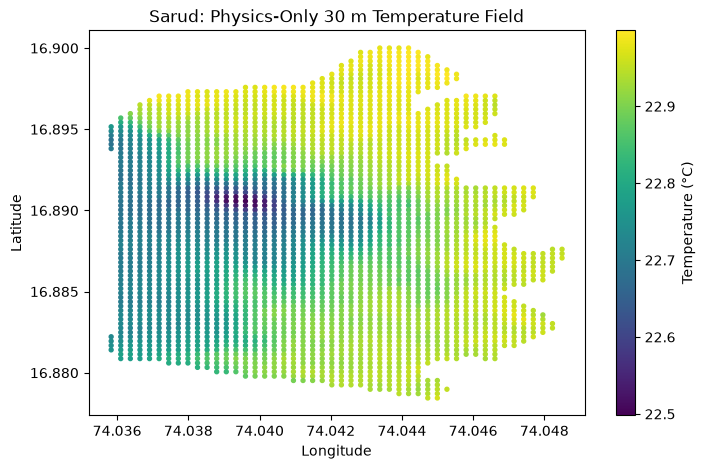

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    sarud_terrain_df["lon"],
    sarud_terrain_df["lat"],
    c=sarud_prediction_C,
    s=8
)

plt.colorbar(label="Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sarud: Physics-Only 30 m Temperature Field")

plt.show()

In [39]:
village_terrain = {}

for station, village_name in {
    "Sarud": "Wadicharan",
    "Patryachiwadi": "Gavashi",
    "Chandgad_1": "Chandgad",
    "Rukadi": "Rukadi"
}.items():

    village_row = selected_villages[
        selected_villages["NAME"] == village_name
    ].iloc[0]

    geom = ee.Geometry(
        village_row.geometry.__geo_interface__
    )

    terrain_image = srtm_30m.clip(geom)

    samples = terrain_image.sample(
        region=geom,
        scale=30,
        numPixels=5000,
        geometries=True,
        seed=42
    )

    data = samples.getInfo()["features"]

    terrain_df = pd.DataFrame([
        {
            "lon": f["geometry"]["coordinates"][0],
            "lat": f["geometry"]["coordinates"][1],
            "elevation_m": f["properties"]["elevation"]
        }
        for f in data
    ])

    village_terrain[station] = terrain_df

    print(
        station,
        "| village:", village_name,
        "| pixels:", len(terrain_df),
        "| elevation:",
        terrain_df["elevation_m"].min(),
        "to",
        terrain_df["elevation_m"].max(),
        "m"
    )

Sarud | village: Wadicharan | pixels: 2769 | elevation: 550 to 627 m
Patryachiwadi | village: Gavashi | pixels: 4952 | elevation: 552 to 867 m
Chandgad_1 | village: Chandgad | pixels: 4917 | elevation: 695 to 1021 m
Rukadi | village: Rukadi | pixels: 4982 | elevation: 530 to 586 m


In [40]:
station_elevations = {}

for station, (lat, lon) in test_stations.items():
    point = ee.Geometry.Point([lon, lat])

    elevation = srtm_30m.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point,
        scale=30
    ).get("elevation").getInfo()

    station_elevations[station] = elevation

    print(station, "| station elevation:", elevation, "m")

Sarud | station elevation: 554 m
Patryachiwadi | station elevation: 557 m
Chandgad_1 | station elevation: 715 m
Rukadi | station elevation: 561 m


In [41]:
validation_physics = validation_compare.copy()

fine_elev_all = (
    validation_physics["Station"]
    .map(station_elevations)
    .to_numpy()
)

coarse_temp_all = (
    validation_physics["era5_temperature_K"]
    .to_numpy()
)

coarse_elev_all = (
    validation_physics["era5_elevation_m"]
    .to_numpy()
)

validation_physics["physics_prediction_K"] = downscale_temperature(
    coarse_temp=coarse_temp_all,
    coarse_elev=coarse_elev_all,
    fine_elev=fine_elev_all,
    lapse_rate=6.5
)

validation_physics["physics_prediction_C"] = (
    validation_physics["physics_prediction_K"] - 273.15
)

validation_physics["residual_C"] = (
    validation_physics["Air Temperature Telemetry Hourly (AoC)"]
    - validation_physics["physics_prediction_C"]
)

print("Records:", len(validation_physics))
print(validation_physics[
    [
        "Station",
        "hour_utc",
        "Air Temperature Telemetry Hourly (AoC)",
        "physics_prediction_C",
        "residual_C"
    ]
].head())

Records: 563
      Station                  hour_utc  \
0  Chandgad_1 2023-07-14 18:00:00+00:00   
1  Chandgad_1 2023-07-14 19:00:00+00:00   
2  Chandgad_1 2023-07-14 20:00:00+00:00   
3  Chandgad_1 2023-07-14 21:00:00+00:00   
4  Chandgad_1 2023-07-14 22:00:00+00:00   

   Air Temperature Telemetry Hourly (AoC)  physics_prediction_C  residual_C  
0                                  22.200             21.279753    0.920247  
1                                  22.425             21.294707    1.130293  
2                                  22.350             20.980559    1.369441  
3                                  22.375             21.139586    1.235414  
4                                  22.225             21.825926    0.399074  


In [42]:
mae = np.mean(
    np.abs(
        validation_physics["residual_C"]
    )
)

rmse = np.sqrt(
    np.mean(
        validation_physics["residual_C"] ** 2
    )
)

bias = validation_physics["residual_C"].mean()

print(f"Physics-only MAE:  {mae:.3f} °C")
print(f"Physics-only RMSE: {rmse:.3f} °C")
print(f"Physics-only Bias: {bias:.3f} °C")

Physics-only MAE:  1.083 °C
Physics-only RMSE: 1.367 °C
Physics-only Bias: -0.843 °C


In [43]:
station_metrics = (
    validation_physics
    .groupby("Station")
    .agg(
        MAE=("residual_C", lambda x: np.mean(np.abs(x))),
        RMSE=("residual_C", lambda x: np.sqrt(np.mean(x ** 2))),
        Bias=("residual_C", "mean"),
        Count=("residual_C", "count")
    )
    .round(3)
)

print(station_metrics)

                 MAE   RMSE   Bias  Count
Station                                  
Chandgad_1     0.608  0.812 -0.416    129
Patryachiwadi  2.194  2.277 -2.194    132
Rukadi         0.947  1.110 -0.587    132
Sarud          0.688  0.841 -0.316    170


In [44]:
validation_physics.groupby("Station")["residual_C"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
Station,,,,,,,,
Chandgad_1,129.0,-0.416,0.700,-2.770,-0.745,-0.344,-0.048,1.369
Patryachiwadi,132.0,-2.194,0.611,-4.827,-2.567,-2.219,-1.843,-0.335
Rukadi,132.0,-0.587,0.945,-2.727,-1.243,-0.815,-0.070,1.989
Sarud,170.0,-0.316,0.782,-1.841,-0.916,-0.342,0.134,1.976


In [45]:
elevation_check = pd.DataFrame({
    "Station": list(station_elevations.keys()),
    "SRTM_station_elevation_m": list(station_elevations.values())
})

elevation_check["ERA5_elevation_m"] = (
    validation_physics
    .groupby("Station")["era5_elevation_m"]
    .mean()
    .reindex(elevation_check["Station"])
    .values
)

elevation_check["Elevation_difference_m"] = (
    elevation_check["SRTM_station_elevation_m"]
    - elevation_check["ERA5_elevation_m"]
)

elevation_check.round(1)

,Station,SRTM_station_elevation_m,ERA5_elevation_m,Elevation_difference_m
0,Sarud,554,648.0,-94.0
1,Patryachiwadi,557,633.0,-76.0
2,Chandgad_1,715,725.6,-10.6
3,Rukadi,561,609.2,-48.2


In [46]:
pat = validation_physics[
    validation_physics["Station"] == "Patryachiwadi"
].copy()

pat[
    [
        "hour_utc",
        "Air Temperature Telemetry Hourly (AoC)",
        "physics_prediction_C",
        "residual_C"
    ]
].head(20)

,hour_utc,Air Temperature Telemetry Hourly (AoC),physics_prediction_C,residual_C
129,2023-07-14 18:00:00+00:00,21.050,22.359564,-1.309564
130,2023-07-14 19:00:00+00:00,21.350,22.187750,-0.837750
131,2023-07-14 20:00:00+00:00,21.525,21.859899,-0.334899
132,2023-07-14 21:00:00+00:00,21.475,22.026373,-0.551373
133,2023-07-14 22:00:00+00:00,21.350,22.938909,-1.588909
134,2023-07-14 23:00:00+00:00,21.575,22.897833,-1.322833
135,2023-07-15 00:00:00+00:00,21.475,24.325811,-2.850811
136,2023-07-15 01:00:00+00:00,21.450,24.433142,-2.983142
137,2023-07-15 02:00:00+00:00,21.950,24.527380,-2.577380
138,2023-07-15 03:00:00+00:00,22.525,24.505560,-1.980560


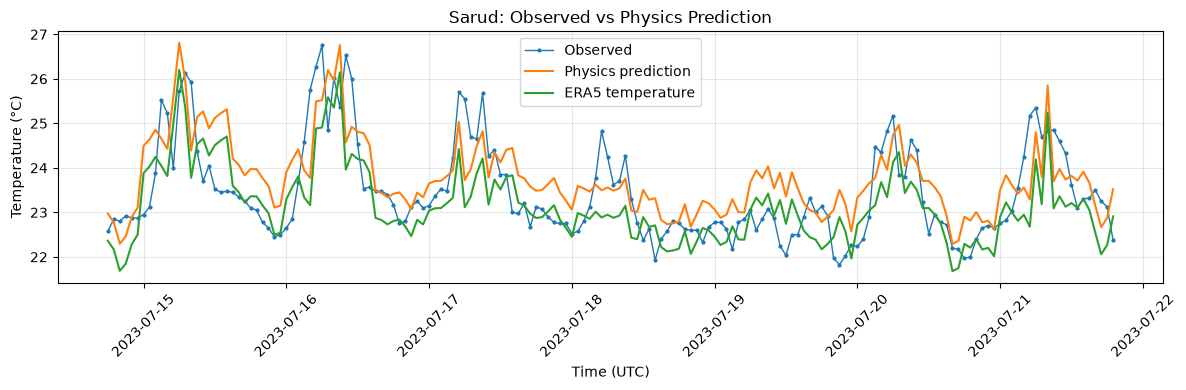

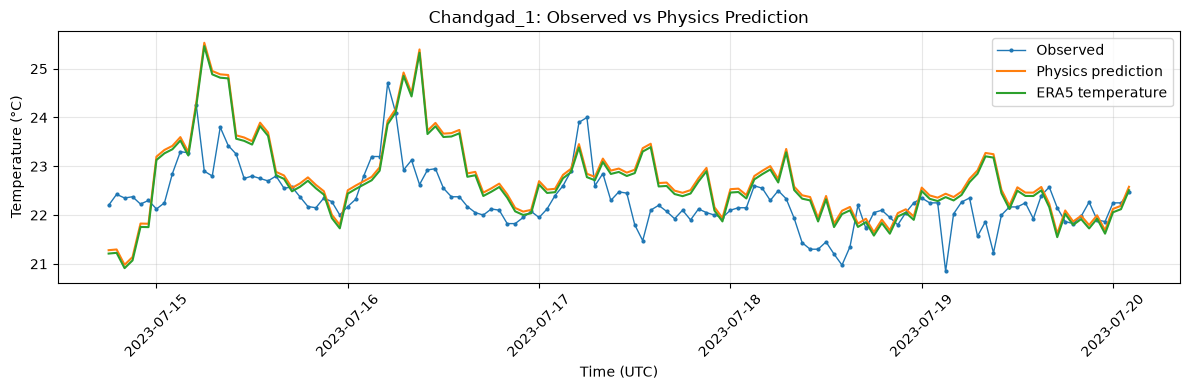

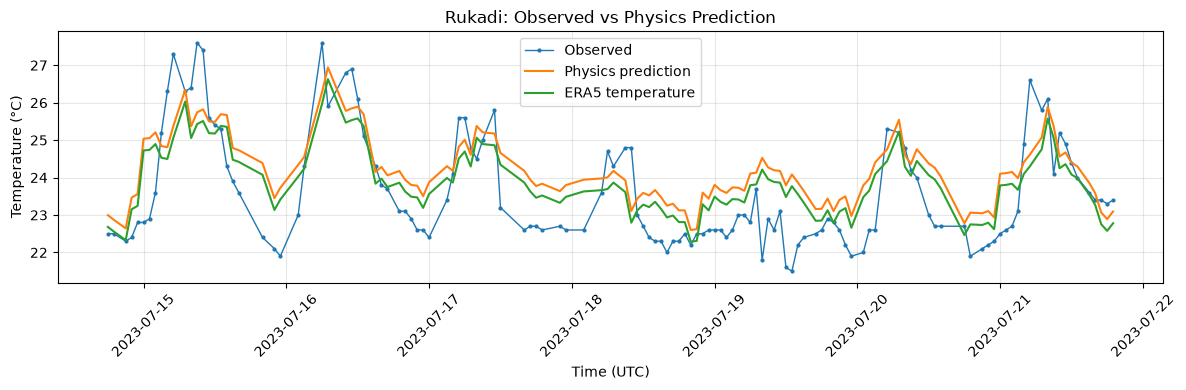

In [47]:
stations_to_plot = ["Sarud", "Chandgad_1", "Rukadi"]

for station in stations_to_plot:
    plot_df = (
        validation_physics[
            validation_physics["Station"] == station
        ]
        .sort_values("hour_utc")
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        plot_df["hour_utc"],
        plot_df["Air Temperature Telemetry Hourly (AoC)"],
        marker="o",
        markersize=2,
        linewidth=1,
        label="Observed"
    )

    plt.plot(
        plot_df["hour_utc"],
        plot_df["physics_prediction_C"],
        linewidth=1.5,
        label="Physics prediction"
    )
    plt.plot(
        plot_df["hour_utc"],
        plot_df["era5_temperature_C"],
        linewidth=1.5,
        label="ERA5 temperature"
    )

    plt.xlabel("Time (UTC)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"{station}: Observed vs Physics Prediction")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [48]:
era5_3month = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate(
        "2023-07-01T00:00:00",
        "2023-10-01T00:00:00"
    )
    .select(["temperature_2m", "geopotential"])
)

print("ERA5 hourly images:", era5_3month.size().getInfo())

ERA5 hourly images: 2208


In [49]:
stations_to_use = {
    "Sarud": (16.89777778, 74.04333333),
    "Chandgad_1": (15.93666667, 74.17694489),
    "Rukadi": (16.72000000, 74.35555600),
}

station_fc_3month = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {"station": station}
    )
    for station, (lat, lon) in stations_to_use.items()
])


def extract_era5_3month(image):
    values = image.reduceRegions(
        collection=station_fc_3month,
        reducer=ee.Reducer.first(),
        scale=27830
    )

    return values.map(
        lambda f: f.set("time", image.date().format())
    )


era5_station_fc_3month = (
    era5_3month
    .map(extract_era5_3month)
    .flatten()
)

era5_station_data_3month = (
    era5_station_fc_3month
    .getInfo()["features"]
)

print("Extracted records:", len(era5_station_data_3month))

EEException: Collection query aborted after accumulating over 5000 elements.

In [50]:
months = [
    ("2023-07-01", "2023-08-01"),
    ("2023-08-01", "2023-09-01"),
    ("2023-09-01", "2023-10-01"),
]

era5_station_data_3month = []

for start, end in months:

    monthly_era5 = era5_3month.filterDate(start, end)

    monthly_fc = (
        monthly_era5
        .map(extract_era5_3month)
        .flatten()
    )

    monthly_data = monthly_fc.getInfo()["features"]

    era5_station_data_3month.extend(monthly_data)

    print(
        start[:7],
        "| ERA5 images:", monthly_era5.size().getInfo(),
        "| extracted records:", len(monthly_data)
    )

print("\nTotal extracted records:", len(era5_station_data_3month))

2023-07 | ERA5 images: 744 | extracted records: 2232
2023-08 | ERA5 images: 744 | extracted records: 2232
2023-09 | ERA5 images: 720 | extracted records: 2160

Total extracted records: 6624


In [51]:
era5_records_3month = []

for feature in era5_station_data_3month:
    props = feature["properties"]

    era5_records_3month.append({
        "Station": props["station"],
        "time": pd.Timestamp(props["time"]),
        "era5_temperature_K": props["temperature_2m"],
        "era5_geopotential": props["geopotential"]
    })

era5_station_df_3month = pd.DataFrame(era5_records_3month)

era5_station_df_3month["time"] = pd.to_datetime(
    era5_station_df_3month["time"],
    utc=True
)

era5_station_df_3month["era5_elevation_m"] = (
    era5_station_df_3month["era5_geopotential"] / 9.80665
)

era5_station_df_3month["era5_temperature_C"] = (
    era5_station_df_3month["era5_temperature_K"] - 273.15
)

print("Shape:", era5_station_df_3month.shape)
print(era5_station_df_3month.head())

Shape: (6624, 6)
      Station                      time  era5_temperature_K  \
0       Sarud 2023-07-01 00:00:00+00:00          296.664581   
1  Chandgad_1 2023-07-01 00:00:00+00:00          296.131348   
2      Rukadi 2023-07-01 00:00:00+00:00          297.529724   
3       Sarud 2023-07-01 01:00:00+00:00          296.713440   
4  Chandgad_1 2023-07-01 01:00:00+00:00          296.037903   

   era5_geopotential  era5_elevation_m  era5_temperature_C  
0        6354.640625        647.993007           23.514581  
1        7116.093750        725.639617           22.981348  
2        5973.914062        609.169702           24.379724  
3        6354.640625        647.993007           23.563440  
4        7116.093750        725.639617           22.887903  


In [ ]:
start_3month = pd.Timestamp("2023-07-01 00:00:00", tz="UTC")
end_3month = pd.Timestamp("2023-09-30 23:00:00", tz="UTC")

station_3month = station_df[
    station_df["Station"].isin(stations_to_use.keys())
].copy()

station_3month["time"] = pd.to_datetime(
    station_3month["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
).dt.tz_localize("Asia/Kolkata")

station_3month["time_utc"] = (
    station_3month["time"]
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

station_3month = station_3month[
    (station_3month["time_utc"] >= start_3month) &
    (station_3month["time_utc"] <= end_3month)
].copy()

hourly_station_3month = (
    station_3month
    .groupby(["Station", "time_utc"])
    ["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

print("Station records:", len(hourly_station_3month))
print(
    hourly_station_3month
    .groupby("Station")
    .size()
)

Station records: 4080
Station
Chandgad_1    1312
Rukadi        1649
Sarud         1119
dtype: int64


In [ ]:
validation_3month = hourly_station_3month.merge(
    era5_station_df_3month,
    left_on=["Station", "time_utc"],
    right_on=["Station", "time"],
    how="inner"
)

print("Matched records:", len(validation_3month))
print(
    validation_3month
    .groupby("Station")
    .size()
)

Matched records: 4080
Station
Chandgad_1    1312
Rukadi        1649
Sarud         1119
dtype: int64


In [ ]:
validation_physics_3month = validation_3month.copy()

fine_elev_3month = (
    validation_physics_3month["Station"]
    .map(station_elevations)
    .to_numpy()
)

coarse_temp_3month = (
    validation_physics_3month["era5_temperature_K"]
    .to_numpy()
)

coarse_elev_3month = (
    validation_physics_3month["era5_elevation_m"]
    .to_numpy()
)

validation_physics_3month["physics_prediction_K"] = downscale_temperature(
    coarse_temp=coarse_temp_3month,
    coarse_elev=coarse_elev_3month,
    fine_elev=fine_elev_3month,
    lapse_rate=6.5
)

validation_physics_3month["physics_prediction_C"] = (
    validation_physics_3month["physics_prediction_K"] - 273.15
)

validation_physics_3month["residual_C"] = (
    validation_physics_3month[
        "Air Temperature Telemetry Hourly (AoC)"
    ]
    - validation_physics_3month["physics_prediction_C"]
)

print("Records:", len(validation_physics_3month))
print(validation_physics_3month.head())

Records: 4080
      Station                  time_utc  \
0  Chandgad_1 2023-07-01 00:00:00+00:00   
1  Chandgad_1 2023-07-01 01:00:00+00:00   
2  Chandgad_1 2023-07-01 02:00:00+00:00   
3  Chandgad_1 2023-07-01 03:00:00+00:00   
4  Chandgad_1 2023-07-01 04:00:00+00:00   

   Air Temperature Telemetry Hourly (AoC)                      time  \
0                                  21.700 2023-07-01 00:00:00+00:00   
1                                  22.075 2023-07-01 01:00:00+00:00   
2                                  22.750 2023-07-01 02:00:00+00:00   
3                                  23.450 2023-07-01 03:00:00+00:00   
4                                  24.275 2023-07-01 04:00:00+00:00   

   era5_temperature_K  era5_geopotential  era5_elevation_m  \
0          296.131348         7116.09375        725.639617   
1          296.037903         7116.09375        725.639617   
2          295.985474         7116.09375        725.639617   
3          295.950439         7116.09375        725.

In [ ]:
metrics_3month = (
    validation_physics_3month
    .groupby("Station")
    .apply(
        lambda df: pd.Series({
            "MAE_C": np.mean(np.abs(df["residual_C"])),
            "RMSE_C": np.sqrt(np.mean(df["residual_C"] ** 2)),
            "Bias_C": df["residual_C"].mean(),
            "Count": len(df)
        }),
        include_groups=False
    )
) # type: ignore

metrics_3month

,MAE_C,RMSE_C,Bias_C,Count
Station,,,,
Chandgad_1,0.886664,1.143694,-0.595650,1312.0
Rukadi,1.240152,1.495155,-0.711576,1649.0
Sarud,1.007757,1.263260,-0.531306,1119.0


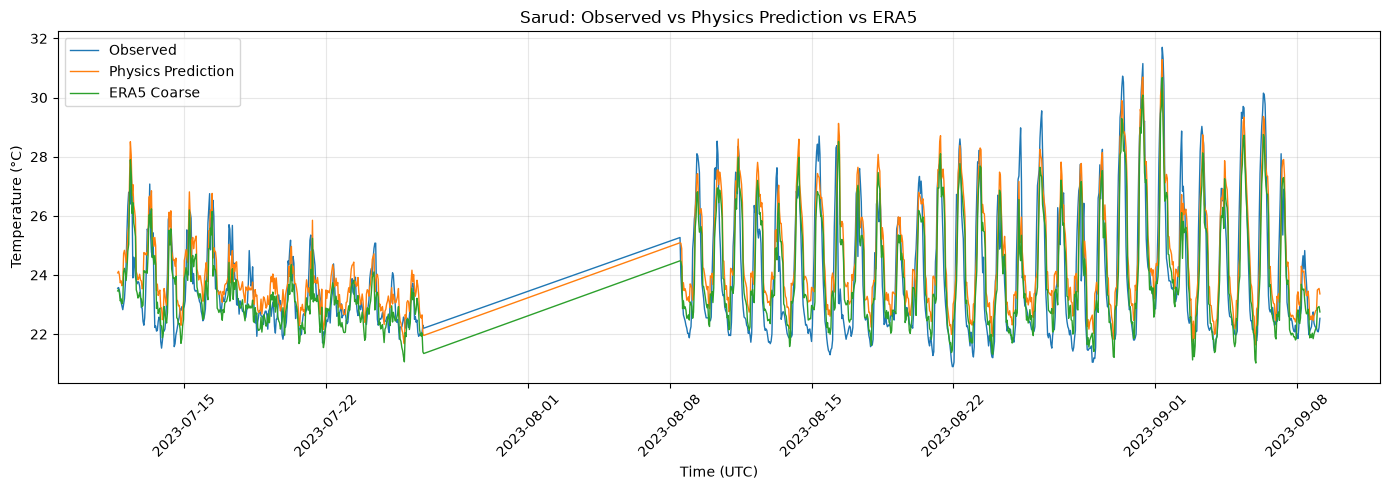

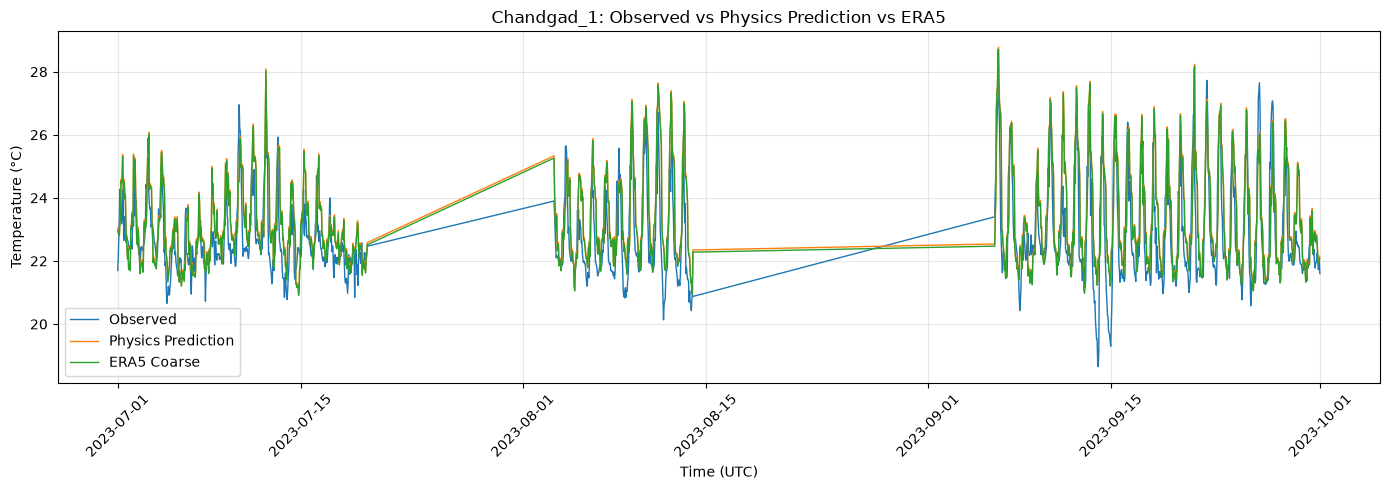

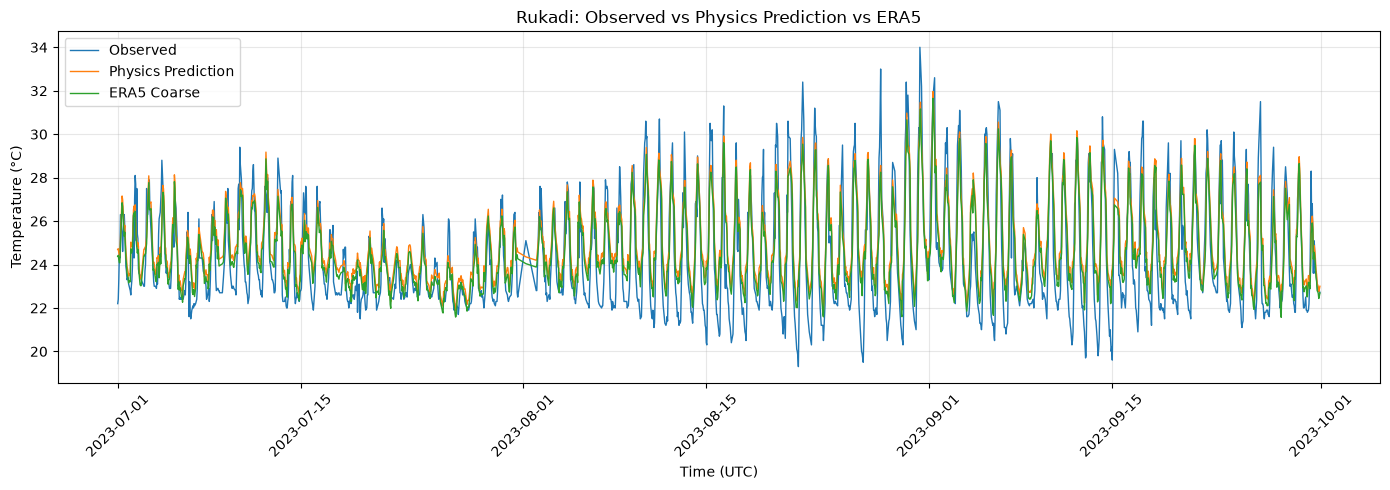

In [ ]:
stations_to_plot = ["Sarud", "Chandgad_1", "Rukadi"]

for station in stations_to_plot:
    plot_df = (
        validation_physics_3month[
            validation_physics_3month["Station"] == station
        ]
        .sort_values("time_utc")
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        plot_df["time_utc"],
        plot_df["Air Temperature Telemetry Hourly (AoC)"],
        linewidth=1,
        label="Observed"
    )

    plt.plot(
        plot_df["time_utc"],
        plot_df["physics_prediction_C"],
        linewidth=1,
        label="Physics Prediction"
    )

    plt.plot(
        plot_df["time_utc"],
        plot_df["era5_temperature_C"],
        linewidth=1,
        label="ERA5 Coarse"
    )

    plt.xlabel("Time (UTC)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"{station}: Observed vs Physics Prediction vs ERA5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
for station in ["Sarud", "Chandgad_1", "Rukadi"]:
    
    times = (
        hourly_station_3month[
            hourly_station_3month["Station"] == station
        ]["time_utc"]
        .sort_values()
    )

    gaps = times.diff().dropna()

    print(f"\n{station}")
    print("Total records:", len(times))
    print("Largest gap:", gaps.max())
    
    print("\nGaps greater than 1 hour:")
    print(
        gaps[gaps > pd.Timedelta(hours=1)]
        .sort_values(ascending=False)
        .head(20)
    )


Sarud
Total records: 1119
Largest gap: 12 days 16:00:00

Gaps greater than 1 hour:
3325   12 days 16:00:00
3996    0 days 05:00:00
3756    0 days 02:00:00
Name: time_utc, dtype: timedelta64[us]

Chandgad_1
Total records: 1312
Largest gap: 23 days 02:00:00

Gaps greater than 1 hour:
714   23 days 02:00:00
459   14 days 07:00:00
461    0 days 02:00:00
Name: time_utc, dtype: timedelta64[us]

Rukadi
Total records: 1649
Largest gap: 0 days 19:00:00

Gaps greater than 1 hour:
1876   0 days 19:00:00
1875   0 days 15:00:00
2679   0 days 06:00:00
1434   0 days 05:00:00
1539   0 days 05:00:00
1350   0 days 05:00:00
1461   0 days 05:00:00
2806   0 days 05:00:00
2496   0 days 05:00:00
2100   0 days 04:00:00
2838   0 days 04:00:00
1615   0 days 04:00:00
1878   0 days 04:00:00
1469   0 days 04:00:00
2536   0 days 04:00:00
2773   0 days 04:00:00
2823   0 days 04:00:00
2421   0 days 04:00:00
1586   0 days 04:00:00
1980   0 days 04:00:00
Name: time_utc, dtype: timedelta64[us]


In [52]:
df = station_df.copy()

# Parse timestamp
df["time"] = pd.to_datetime(
    df["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# Convert IST → UTC
df["time_utc"] = (
    df["time"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

# Remove invalid timestamps
df = df.dropna(subset=["time_utc"])

# Keep only unique station-hours
hourly = (
    df[["Station", "time_utc"]]
    .drop_duplicates()
)

hourly.head()

,Station,time_utc
0,Yeldari dam_1,2025-03-09 07:00:00+00:00
1,Yeldari dam_1,2024-09-23 14:00:00+00:00
2,Yeldari dam_1,2024-02-12 18:00:00+00:00
3,Yeldari dam_1,2025-03-10 03:00:00+00:00
4,Yeldari dam_1,2025-07-15 23:00:00+00:00


In [53]:
hourly["year"] = hourly["time_utc"].dt.year

station_year_stats = []

for (station, year), group in hourly.groupby(["Station", "year"]):

    start = pd.Timestamp(
        f"{year}-01-01 00:00:00",
        tz="UTC"
    )

    end = pd.Timestamp(
        f"{year}-12-31 23:00:00",
        tz="UTC"
    )

    expected = pd.date_range(
        start,
        end,
        freq="h"
    )

    actual = pd.DatetimeIndex(
        group["time_utc"].sort_values().unique()
    )

    missing = expected.difference(actual)

    gaps = actual.to_series().diff().dropna()

    station_year_stats.append({
        "Station": station,
        "Year": year,
        "Expected_hours": len(expected),
        "Actual_hours": len(actual),
        "Missing_hours": len(missing),
        "Coverage_pct": 100 * len(actual) / len(expected),
        "Largest_gap_hours": gaps.dt.total_seconds().max() / 3600
            if len(gaps) else 0,
        "Gaps_gt_1h": (gaps > pd.Timedelta(hours=1)).sum(),
        "Gaps_gt_24h": (gaps > pd.Timedelta(hours=24)).sum()
    })

station_year_stats = pd.DataFrame(station_year_stats)

station_year_stats = station_year_stats.sort_values(
    ["Coverage_pct", "Largest_gap_hours"],
    ascending=[False, True]
)

station_year_stats.head(30)

,Station,Year,Expected_hours,Actual_hours,Missing_hours,Coverage_pct,Largest_gap_hours,Gaps_gt_1h,Gaps_gt_24h
14,Aurangpur,2023,8760,8647,113,98.710046,16.0,21,0
27,Bhatsanagar_1,2024,8784,8435,349,96.026867,9.0,246,0
170,Natuwadi Dam_1,2024,8784,8422,362,95.878871,9.0,251,0
18,Awadshirpur_1,2024,8784,8347,437,95.025046,118.0,164,3
248,Shahgad,2024,8784,8325,459,94.774590,160.0,154,2
146,Masoli_1,2024,8784,8307,477,94.569672,207.0,157,2
137,Manasgaon,2024,8784,8289,495,94.364754,36.0,333,1
122,Lower Wardha,2024,8784,8289,495,94.364754,47.0,312,3
15,Aurangpur,2024,8784,8275,509,94.205373,23.0,351,0
48,Burai Dam_1,2024,8784,8266,518,94.102914,48.0,363,1


In [56]:
good_station_years = station_year_stats[
    (station_year_stats["Coverage_pct"] >= 95) &
    (station_year_stats["Largest_gap_hours"] <= 24)
].copy()

good_station_years.count()

Station              3
Year                 3
Expected_hours       3
Actual_hours         3
Missing_hours        3
Coverage_pct         3
Largest_gap_hours    3
Gaps_gt_1h           3
Gaps_gt_24h          3
dtype: int64

In [57]:
good_station_years = station_year_stats[
    (station_year_stats["Coverage_pct"] >= 95) &
    (station_year_stats["Largest_gap_hours"] <= 24) &
    (station_year_stats["Gaps_gt_24h"] == 0)
].copy()

good_station_years.sort_values(
    "Coverage_pct",
    ascending=False
).head(30) # type: ignore

,Station,Year,Expected_hours,Actual_hours,Missing_hours,Coverage_pct,Largest_gap_hours,Gaps_gt_1h,Gaps_gt_24h
14,Aurangpur,2023,8760,8647,113,98.710046,16.0,21,0
27,Bhatsanagar_1,2024,8784,8435,349,96.026867,9.0,246,0
170,Natuwadi Dam_1,2024,8784,8422,362,95.878871,9.0,251,0


In [58]:
candidate_stations = good_station_years["Station"].unique()

station_locations = (
    station_df[
        station_df["Station"].isin(candidate_stations)
    ][["Station", "Latitude", "Longitude"]]
    .drop_duplicates("Station")
)

station_gdf = gpd.GeoDataFrame(
    station_locations,
    geometry=gpd.points_from_xy(
        station_locations["Longitude"],
        station_locations["Latitude"]
    ),
    crs="EPSG:4326"
)

station_villages = gpd.sjoin(
    station_gdf,
    mh[["NAME", "DISTRICT", "SUB_DIST", "geometry"]],
    how="left",
    predicate="within"
)

station_villages[
    ["Station", "Latitude", "Longitude", "NAME", "DISTRICT", "SUB_DIST"]
]

,Station,Latitude,Longitude,NAME,DISTRICT,SUB_DIST
1367463,Natuwadi Dam_1,17.332778,73.400000,Murtavade,Ratnagiri,Chiplun
2559139,Bhatsanagar_1,19.519534,73.409324,Shende,Thane,Shahapur
2695642,Aurangpur,20.821111,77.540833,Bapori,Akola,Murtijapur


In [59]:
candidate_check = station_villages[
    station_villages["Station"].isin(
        ["Aurangpur", "Bhatsanagar_1", "Natuwadi Dam_1"]
    )
].copy()

candidate_check[
    ["Station", "Latitude", "Longitude", "NAME", "DISTRICT", "SUB_DIST"]
]

,Station,Latitude,Longitude,NAME,DISTRICT,SUB_DIST
1367463,Natuwadi Dam_1,17.332778,73.400000,Murtavade,Ratnagiri,Chiplun
2559139,Bhatsanagar_1,19.519534,73.409324,Shende,Thane,Shahapur
2695642,Aurangpur,20.821111,77.540833,Bapori,Akola,Murtijapur


In [60]:
candidate_points = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Point([row.Longitude, row.Latitude]),
        {"Station": row.Station}
    )
    for row in candidate_check.itertuples()
])

candidate_elevations = srtm.reduceRegions(
    collection=candidate_points,
    reducer=ee.Reducer.first(),
    scale=30
).getInfo()

candidate_elevations

{'type': 'FeatureCollection',
 'columns': {'Station': 'String', 'first': 'Short', 'system:index': 'String'},
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [73.4, 17.33277778]},
   'id': '0',
   'properties': {'Station': 'Natuwadi Dam_1', 'first': 207}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [73.409324, 19.519534]},
   'id': '1',
   'properties': {'Station': 'Bhatsanagar_1', 'first': 186}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [77.54083333, 20.82111111]},
   'id': '2',
   'properties': {'Station': 'Aurangpur', 'first': 286}}]}

In [61]:
candidate_stations = {
    "Aurangpur": (20.82111111, 77.54083333),
    "Bhatsanagar_1": (19.519534, 73.409324),
    "Natuwadi Dam_1": (17.33277778, 73.400000)
}

candidate_points = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {"Station": station}
    )
    for station, (lat, lon) in candidate_stations.items()
])

candidate_points.getInfo()

{'type': 'FeatureCollection',
 'columns': {'Station': 'String', 'system:index': 'String'},
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [77.54083333, 20.82111111]},
   'id': '0',
   'properties': {'Station': 'Aurangpur'}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [73.409324, 19.519534]},
   'id': '1',
   'properties': {'Station': 'Bhatsanagar_1'}},
  {'type': 'Feature',
   'geometry': {'type': 'Point', 'coordinates': [73.4, 17.33277778]},
   'id': '2',
   'properties': {'Station': 'Natuwadi Dam_1'}}]}

In [62]:
era5_jan = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate("2023-01-01T00:00:00", "2023-02-01T00:00:00")
    .select(["temperature_2m", "geopotential"])
)

jan_records = (
    era5_jan
    .map(
        lambda image: image.reduceRegions(
            collection=candidate_points,
            reducer=ee.Reducer.first(),
            scale=27830
        ).map(
            lambda feature: feature.set(
                "time",
                image.date().format("YYYY-MM-dd HH:mm:ss")
            )
        )
    )
    .flatten()
    .getInfo()["features"]
)

len(jan_records)

2232

In [67]:
candidate_station_years = {
    "Aurangpur": 2023,
    "Bhatsanagar_1": 2024,
    "Natuwadi Dam_1": 2024
}

monthly_records = []

for station, year in candidate_station_years.items():

    station_point = ee.FeatureCollection([
        ee.Feature(
            ee.Geometry.Point([
                candidate_stations[station][1],
                candidate_stations[station][0]
            ]),
            {"Station": station}
        )
    ])

    for month in range(1, 13):

        start = pd.Timestamp(year=year, month=month, day=1)
        end = start + pd.offsets.MonthBegin(1)

        print(f"{station} | {start.strftime('%Y-%m')}")

        era5_month = (
            ee.ImageCollection("ECMWF/ERA5/HOURLY")
            .filterDate(
                start.strftime("%Y-%m-%dT00:00:00"),
                end.strftime("%Y-%m-%dT00:00:00")
            )
            .select(["temperature_2m", "geopotential"])
        )

        records = (
            era5_month
            .map(
                lambda image: image.reduceRegions(
                    collection=station_point,
                    reducer=ee.Reducer.first(),
                    scale=27830
                ).map(
                    lambda feature: feature.set(
                        "time",
                        image.date().format("YYYY-MM-dd HH:mm:ss")
                    )
                )
            )
            .flatten()
            .getInfo()["features"]
        )

        monthly_records.extend([
            {
                "Station": f["properties"].get("Station"),
                "time": f["properties"].get("time"),
                "temperature_K": f["properties"].get("temperature_2m"),
                "geopotential": f["properties"].get("geopotential")
            }
            for f in records
        ])

print(f"\nTotal records: {len(monthly_records)}")

Aurangpur | 2023-01
Aurangpur | 2023-02
Aurangpur | 2023-03
Aurangpur | 2023-04
Aurangpur | 2023-05
Aurangpur | 2023-06
Aurangpur | 2023-07
Aurangpur | 2023-08
Aurangpur | 2023-09
Aurangpur | 2023-10
Aurangpur | 2023-11
Aurangpur | 2023-12
Bhatsanagar_1 | 2024-01
Bhatsanagar_1 | 2024-02
Bhatsanagar_1 | 2024-03
Bhatsanagar_1 | 2024-04
Bhatsanagar_1 | 2024-05
Bhatsanagar_1 | 2024-06
Bhatsanagar_1 | 2024-07
Bhatsanagar_1 | 2024-08
Bhatsanagar_1 | 2024-09
Bhatsanagar_1 | 2024-10
Bhatsanagar_1 | 2024-11
Bhatsanagar_1 | 2024-12
Natuwadi Dam_1 | 2024-01
Natuwadi Dam_1 | 2024-02
Natuwadi Dam_1 | 2024-03
Natuwadi Dam_1 | 2024-04
Natuwadi Dam_1 | 2024-05
Natuwadi Dam_1 | 2024-06
Natuwadi Dam_1 | 2024-07
Natuwadi Dam_1 | 2024-08
Natuwadi Dam_1 | 2024-09
Natuwadi Dam_1 | 2024-10
Natuwadi Dam_1 | 2024-11
Natuwadi Dam_1 | 2024-12

Total records: 26328


In [68]:
era5_station_df_1year = pd.DataFrame(monthly_records)

era5_station_df_1year["time"] = pd.to_datetime(
    era5_station_df_1year["time"],
    utc=True
)

era5_station_df_1year["temperature_C"] = (
    era5_station_df_1year["temperature_K"] - 273.15
)

era5_station_df_1year["era5_elevation_m"] = (
    era5_station_df_1year["geopotential"] / 9.80665
)

era5_station_df_1year = (
    era5_station_df_1year
    .sort_values(["Station", "time"])
    .reset_index(drop=True)
)

print(era5_station_df_1year.shape)
era5_station_df_1year.head()

(26328, 6)


,Station,time,temperature_K,geopotential,temperature_C,era5_elevation_m
0,Aurangpur,2023-01-01 00:00:00+00:00,289.324127,3167.853516,16.174127,323.031159
1,Aurangpur,2023-01-01 01:00:00+00:00,289.392395,3167.853516,16.242395,323.031159
2,Aurangpur,2023-01-01 02:00:00+00:00,290.498932,3167.853516,17.348932,323.031159
3,Aurangpur,2023-01-01 03:00:00+00:00,291.994019,3167.853516,18.844019,323.031159
4,Aurangpur,2023-01-01 04:00:00+00:00,293.025513,3167.853516,19.875513,323.031159


In [71]:
candidate_obs = station_df[
    station_df["Station"].isin(candidate_station_years.keys())
].copy()

candidate_obs["time"] = pd.to_datetime(
    candidate_obs["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

candidate_obs["time_utc"] = (
    candidate_obs["time"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

candidate_obs = candidate_obs.dropna(subset=["time_utc"])

candidate_obs["observed_temperature_C"] = (
    candidate_obs["Air Temperature Telemetry Hourly (AoC)"]
)

candidate_obs_hourly = (
    candidate_obs
    .groupby(["Station", "time_utc"])["observed_temperature_C"]
    .mean()
    .reset_index()
)

candidate_obs_hourly.head()

,Station,time_utc,observed_temperature_C
0,Aurangpur,2021-06-02 11:00:00+00:00,0.0
1,Aurangpur,2021-06-02 12:00:00+00:00,0.0
2,Aurangpur,2021-06-02 13:00:00+00:00,0.0
3,Aurangpur,2021-06-02 14:00:00+00:00,0.0
4,Aurangpur,2021-06-03 11:00:00+00:00,0.0


In [72]:
candidate_obs_hourly["year"] = (
    candidate_obs_hourly["time_utc"].dt.year
)

candidate_obs_hourly = candidate_obs_hourly[
    (
        (candidate_obs_hourly["Station"] == "Aurangpur") &
        (candidate_obs_hourly["year"] == 2023)
    )
    |
    (
        (candidate_obs_hourly["Station"].isin(
            ["Bhatsanagar_1", "Natuwadi Dam_1"]
        )) &
        (candidate_obs_hourly["year"] == 2024)
    )
].drop(columns="year")

print(candidate_obs_hourly.shape)

(25504, 3)


In [73]:
validation_1year = candidate_obs_hourly.merge(
    era5_station_df_1year,
    left_on=["Station", "time_utc"],
    right_on=["Station", "time"],
    how="inner"
)

print(validation_1year.shape)
validation_1year.head()

(25504, 8)


,Station,time_utc,observed_temperature_C,time,temperature_K,geopotential,temperature_C,era5_elevation_m
0,Aurangpur,2023-01-01 00:00:00+00:00,13.2,2023-01-01 00:00:00+00:00,289.324127,3167.853516,16.174127,323.031159
1,Aurangpur,2023-01-01 01:00:00+00:00,12.3,2023-01-01 01:00:00+00:00,289.392395,3167.853516,16.242395,323.031159
2,Aurangpur,2023-01-01 02:00:00+00:00,14.6,2023-01-01 02:00:00+00:00,290.498932,3167.853516,17.348932,323.031159
3,Aurangpur,2023-01-01 03:00:00+00:00,19.5,2023-01-01 03:00:00+00:00,291.994019,3167.853516,18.844019,323.031159
4,Aurangpur,2023-01-01 04:00:00+00:00,22.2,2023-01-01 04:00:00+00:00,293.025513,3167.853516,19.875513,323.031159


In [74]:
validation_1year.groupby("Station").size()

Station
Aurangpur         8647
Bhatsanagar_1     8435
Natuwadi Dam_1    8422
dtype: int64

In [75]:
station_srtm_elev = {
    "Natuwadi Dam_1": 207,
    "Bhatsanagar_1": 186,
    "Aurangpur": 286
}

validation_1year["srtm_elevation_m"] = (
    validation_1year["Station"].map(station_srtm_elev)
)

validation_1year["elevation_difference_m"] = (
    validation_1year["srtm_elevation_m"]
    - validation_1year["era5_elevation_m"]
)

validation_1year["physics_prediction_C"] = (
    validation_1year["temperature_C"]
    - 6.5
    * validation_1year["elevation_difference_m"]
    / 1000
)

validation_1year["residual_C"] = (
    validation_1year["observed_temperature_C"]
    - validation_1year["physics_prediction_C"]
)

validation_1year[
    [
        "Station",
        "time_utc",
        "observed_temperature_C",
        "temperature_C",
        "era5_elevation_m",
        "srtm_elevation_m",
        "physics_prediction_C",
        "residual_C"
    ]
].head()

,Station,time_utc,observed_temperature_C,temperature_C,era5_elevation_m,srtm_elevation_m,physics_prediction_C,residual_C
0,Aurangpur,2023-01-01 00:00:00+00:00,13.2,16.174127,323.031159,286,16.414830,-3.214830
1,Aurangpur,2023-01-01 01:00:00+00:00,12.3,16.242395,323.031159,286,16.483098,-4.183098
2,Aurangpur,2023-01-01 02:00:00+00:00,14.6,17.348932,323.031159,286,17.589634,-2.989634
3,Aurangpur,2023-01-01 03:00:00+00:00,19.5,18.844019,323.031159,286,19.084721,0.415279
4,Aurangpur,2023-01-01 04:00:00+00:00,22.2,19.875513,323.031159,286,20.116215,2.083785


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

overall_mae = mean_absolute_error(
    validation_1year["observed_temperature_C"],
    validation_1year["physics_prediction_C"]
)

overall_rmse = np.sqrt(
    mean_squared_error(
        validation_1year["observed_temperature_C"],
        validation_1year["physics_prediction_C"]
    )
)

overall_bias = (
    validation_1year["physics_prediction_C"]
    - validation_1year["observed_temperature_C"]
).mean()

print(f"Overall MAE:  {overall_mae:.3f} °C")
print(f"Overall RMSE: {overall_rmse:.3f} °C")
print(f"Overall Bias: {overall_bias:.3f} °C")

Overall MAE:  2.050 °C
Overall RMSE: 3.405 °C
Overall Bias: 0.646 °C


In [77]:
station_metrics = []

for station, group in validation_1year.groupby("Station"):

    mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["physics_prediction_C"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["observed_temperature_C"],
            group["physics_prediction_C"]
        )
    )

    bias = (
        group["physics_prediction_C"]
        - group["observed_temperature_C"]
    ).mean()

    station_metrics.append({
        "Station": station,
        "Count": len(group),
        "MAE_C": mae,
        "RMSE_C": rmse,
        "Bias_C": bias
    })

station_metrics = pd.DataFrame(station_metrics)

station_metrics

,Station,Count,MAE_C,RMSE_C,Bias_C
0,Aurangpur,8647,2.534455,3.955664,1.378645
1,Bhatsanagar_1,8435,1.881846,2.765819,0.028927
2,Natuwadi Dam_1,8422,1.720890,3.372700,0.510577


In [78]:
validation_1year["month"] = validation_1year["time_utc"].dt.month

monthly_metrics = []

for (station, month), group in validation_1year.groupby(
    ["Station", "month"]
):

    mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["physics_prediction_C"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["observed_temperature_C"],
            group["physics_prediction_C"]
        )
    )

    bias = (
        group["physics_prediction_C"]
        - group["observed_temperature_C"]
    ).mean()

    monthly_metrics.append({
        "Station": station,
        "Month": month,
        "Count": len(group),
        "MAE_C": mae,
        "RMSE_C": rmse,
        "Bias_C": bias
    })

monthly_metrics = pd.DataFrame(monthly_metrics)

monthly_metrics

,Station,Month,Count,MAE_C,RMSE_C,Bias_C
0,Aurangpur,1,687,3.011641,3.920497,2.063543
1,Aurangpur,2,664,4.119643,5.578832,2.601328
2,Aurangpur,3,720,2.986473,4.202461,1.545855
3,Aurangpur,4,720,2.662671,4.472870,1.413549
4,Aurangpur,5,744,2.303561,4.064583,0.950567
5,Aurangpur,6,720,1.810392,3.240867,0.665085
6,Aurangpur,7,744,1.416125,3.447316,0.647630
7,Aurangpur,8,743,1.216806,1.738639,0.390465
8,Aurangpur,9,698,1.887417,3.464642,0.879512
9,Aurangpur,10,743,3.383017,4.648442,2.266965


In [79]:
natuwadi_aug = validation_1year[
    (validation_1year["Station"] == "Natuwadi Dam_1") &
    (validation_1year["time_utc"].dt.month == 8)
].copy()

natuwadi_aug["abs_error"] = (
    natuwadi_aug["physics_prediction_C"]
    - natuwadi_aug["observed_temperature_C"]
).abs()

natuwadi_aug.sort_values(
    "abs_error",
    ascending=False
)[[
    "time_utc",
    "observed_temperature_C",
    "temperature_C",
    "physics_prediction_C",
    "residual_C",
    "abs_error"
]].head(20)

,time_utc,observed_temperature_C,temperature_C,physics_prediction_C,residual_C,abs_error
22190,2024-08-05 06:00:00+00:00,0.0,27.778284,27.938509,-27.938509,27.938509
22192,2024-08-05 08:00:00+00:00,0.0,27.636774,27.796999,-27.796999,27.796999
22194,2024-08-05 10:00:00+00:00,0.0,27.386438,27.546663,-27.546663,27.546663
22195,2024-08-05 11:00:00+00:00,0.0,27.097772,27.257998,-27.257998,27.257998
22148,2024-08-03 09:00:00+00:00,0.0,27.063531,27.223757,-27.223757,27.223757
22193,2024-08-05 09:00:00+00:00,0.0,26.872705,27.032930,-27.032930,27.032930
22124,2024-08-02 09:00:00+00:00,0.0,26.735559,26.895784,-26.895784,26.895784
22172,2024-08-04 09:00:00+00:00,0.0,26.548975,26.709200,-26.709200,26.709200
22122,2024-08-02 07:00:00+00:00,0.0,26.528009,26.688234,-26.688234,26.688234
22147,2024-08-03 08:00:00+00:00,0.0,26.503809,26.664034,-26.664034,26.664034


In [80]:
zero_check = (
    validation_1year[
        "observed_temperature_C"
    ] == 0
).sum()

print("Zero observations:", zero_check)
print(
    "Percentage:",
    100 * zero_check / len(validation_1year)
)

Zero observations: 180
Percentage: 0.705771643663739


In [81]:
validation_1year.groupby("Station").apply(
    lambda x: (x["observed_temperature_C"] == 0).sum()
)

Station
Aurangpur          77
Bhatsanagar_1       1
Natuwadi Dam_1    102
dtype: int64

In [82]:
validation_1year[
    validation_1year["observed_temperature_C"] == 0
].groupby(
    ["Station", validation_1year["time_utc"].dt.month]
).size()

Station         time_utc
Aurangpur       1            4
                2            9
                3            5
                4            9
                5            7
                6            4
                7           10
                8            1
                9            8
                10           8
                11           4
                12           8
Bhatsanagar_1   1            1
Natuwadi Dam_1  4            4
                7            1
                8           97
dtype: int64

In [83]:
zero_counts = (
    validation_1year
    .assign(is_zero=lambda x: x["observed_temperature_C"] == 0)
    .groupby("Station")["is_zero"]
    .agg(["sum", "mean"])
)

zero_counts["mean"] *= 100

zero_counts

,sum,mean
Station,,
Aurangpur,77,0.890482
Bhatsanagar_1,1,0.011855
Natuwadi Dam_1,102,1.211114


In [84]:
validation_clean = validation_1year.copy()

validation_clean.loc[
    validation_clean["observed_temperature_C"] == 0,
    "observed_temperature_C"
] = np.nan

validation_clean = validation_clean.dropna(
    subset=["observed_temperature_C"]
)

print("Original rows:", len(validation_1year))
print("Clean rows:", len(validation_clean))

Original rows: 25504
Clean rows: 25324


In [85]:
validation_clean["observed_temperature_C"].describe()

count    25324.000000
mean        26.650843
std          5.973433
min          2.000000
25%         23.700000
50%         26.300000
75%         30.300000
max         44.700000
Name: observed_temperature_C, dtype: float64

In [86]:
overall_mae_clean = mean_absolute_error(
    validation_clean["observed_temperature_C"],
    validation_clean["physics_prediction_C"]
)

overall_rmse_clean = np.sqrt(
    mean_squared_error(
        validation_clean["observed_temperature_C"],
        validation_clean["physics_prediction_C"]
    )
)

overall_bias_clean = (
    validation_clean["physics_prediction_C"]
    - validation_clean["observed_temperature_C"]
).mean()

print(f"Overall MAE:  {overall_mae_clean:.3f} °C")
print(f"Overall RMSE: {overall_rmse_clean:.3f} °C")
print(f"Overall Bias: {overall_bias_clean:.3f} °C")

Overall MAE:  1.879 °C
Overall RMSE: 2.596 °C
Overall Bias: 0.465 °C


In [87]:
station_metrics_clean = []

for station, group in validation_clean.groupby("Station"):

    mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["physics_prediction_C"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["observed_temperature_C"],
            group["physics_prediction_C"]
        )
    )

    bias = (
        group["physics_prediction_C"]
        - group["observed_temperature_C"]
    ).mean()

    station_metrics_clean.append({
        "Station": station,
        "Count": len(group),
        "MAE_C": mae,
        "RMSE_C": rmse,
        "Bias_C": bias
    })

station_metrics_clean = pd.DataFrame(station_metrics_clean)

station_metrics_clean

,Station,Count,MAE_C,RMSE_C,Bias_C
0,Aurangpur,8570,2.315935,3.007917,1.149740
1,Bhatsanagar_1,8434,1.878772,2.749364,0.025634
2,Natuwadi Dam_1,8320,1.429402,1.880319,0.204251


In [88]:
validation_clean["month"] = validation_clean["time_utc"].dt.month

monthly_metrics_clean = []

for (station, month), group in validation_clean.groupby(
    ["Station", "month"]
):

    mae = mean_absolute_error(
        group["observed_temperature_C"],
        group["physics_prediction_C"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["observed_temperature_C"],
            group["physics_prediction_C"]
        )
    )

    bias = (
        group["physics_prediction_C"]
        - group["observed_temperature_C"]
    ).mean()

    monthly_metrics_clean.append({
        "Station": station,
        "Month": month,
        "Count": len(group),
        "MAE_C": mae,
        "RMSE_C": rmse,
        "Bias_C": bias
    })

monthly_metrics_clean = pd.DataFrame(monthly_metrics_clean)

monthly_metrics_clean

,Station,Month,Count,MAE_C,RMSE_C,Bias_C
0,Aurangpur,1,683,2.900549,3.545199,1.946899
1,Aurangpur,2,655,3.804458,4.579270,2.265281
2,Aurangpur,3,715,2.827587,3.615721,1.376895
3,Aurangpur,4,711,2.319419,2.955699,1.054486
4,Aurangpur,5,737,2.011569,2.472702,0.645725
5,Aurangpur,6,716,1.653788,2.347400,0.502082
6,Aurangpur,7,734,1.066460,1.414147,0.287495
7,Aurangpur,8,742,1.183786,1.461345,0.356331
8,Aurangpur,9,690,1.597313,1.925661,0.577723
9,Aurangpur,10,735,3.117825,3.645760,1.989626


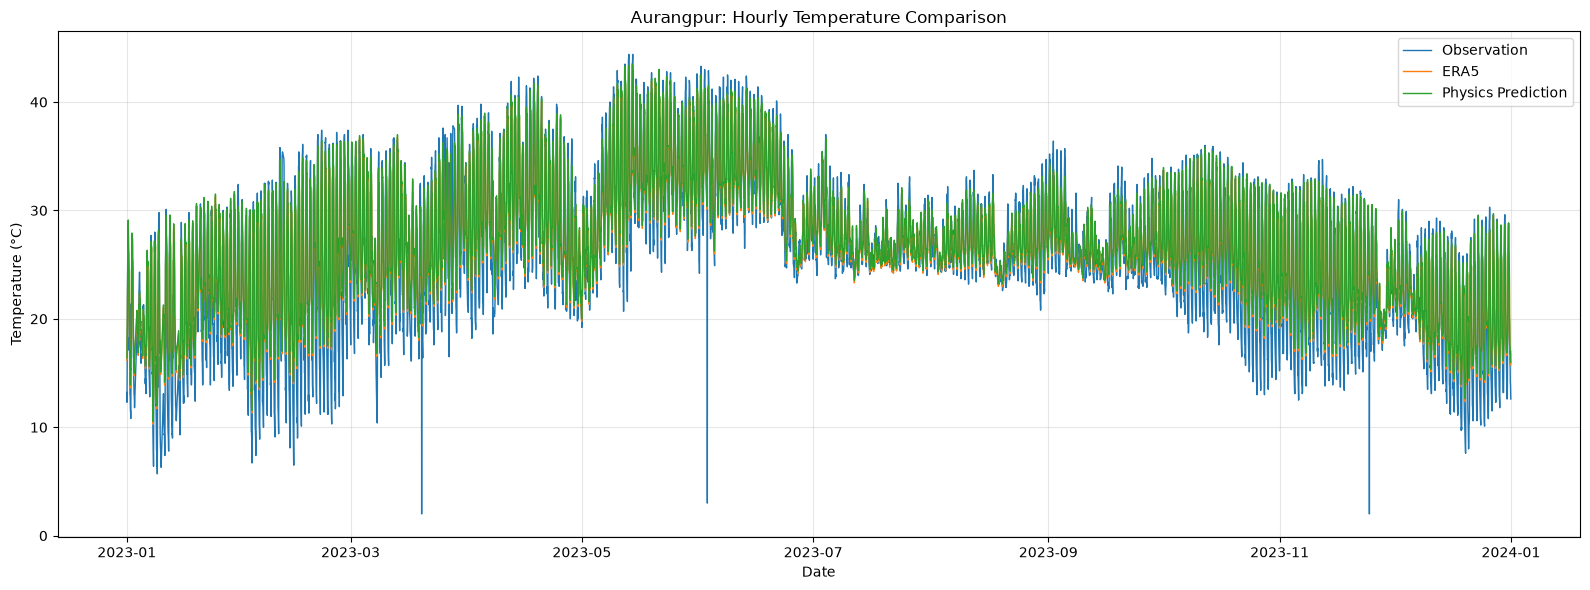

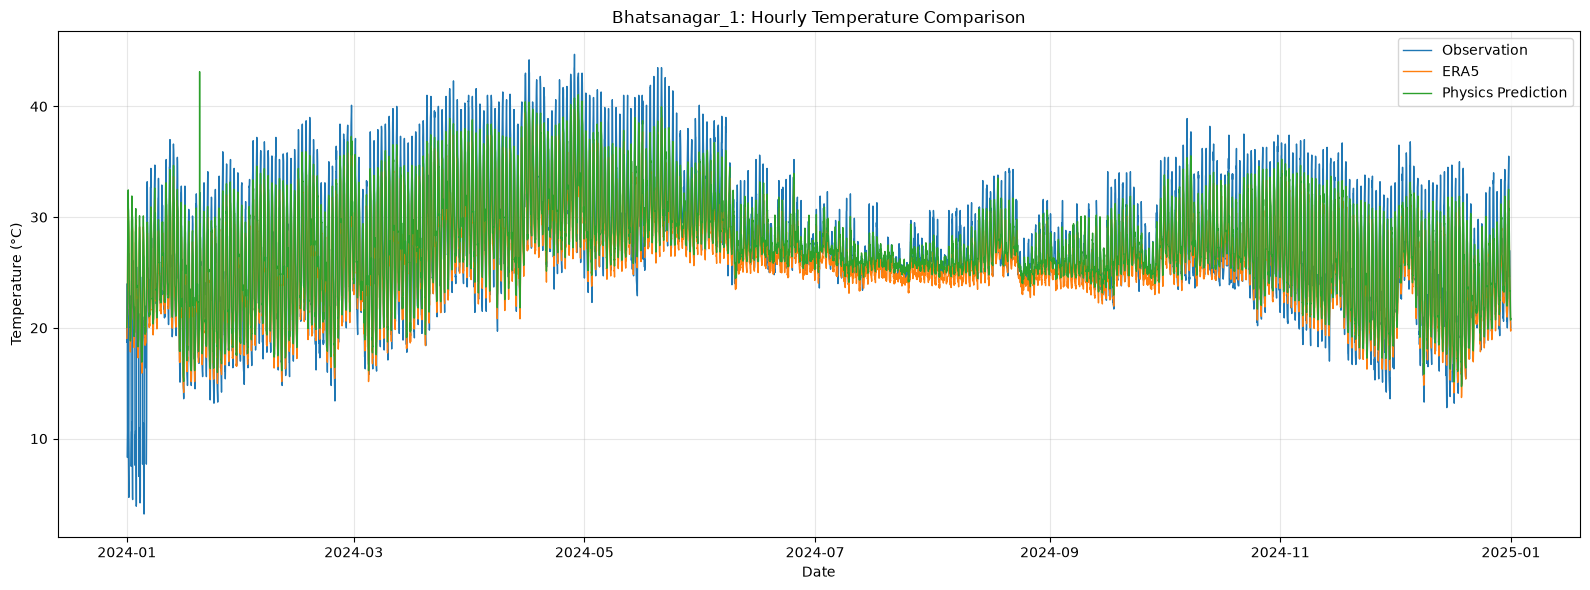

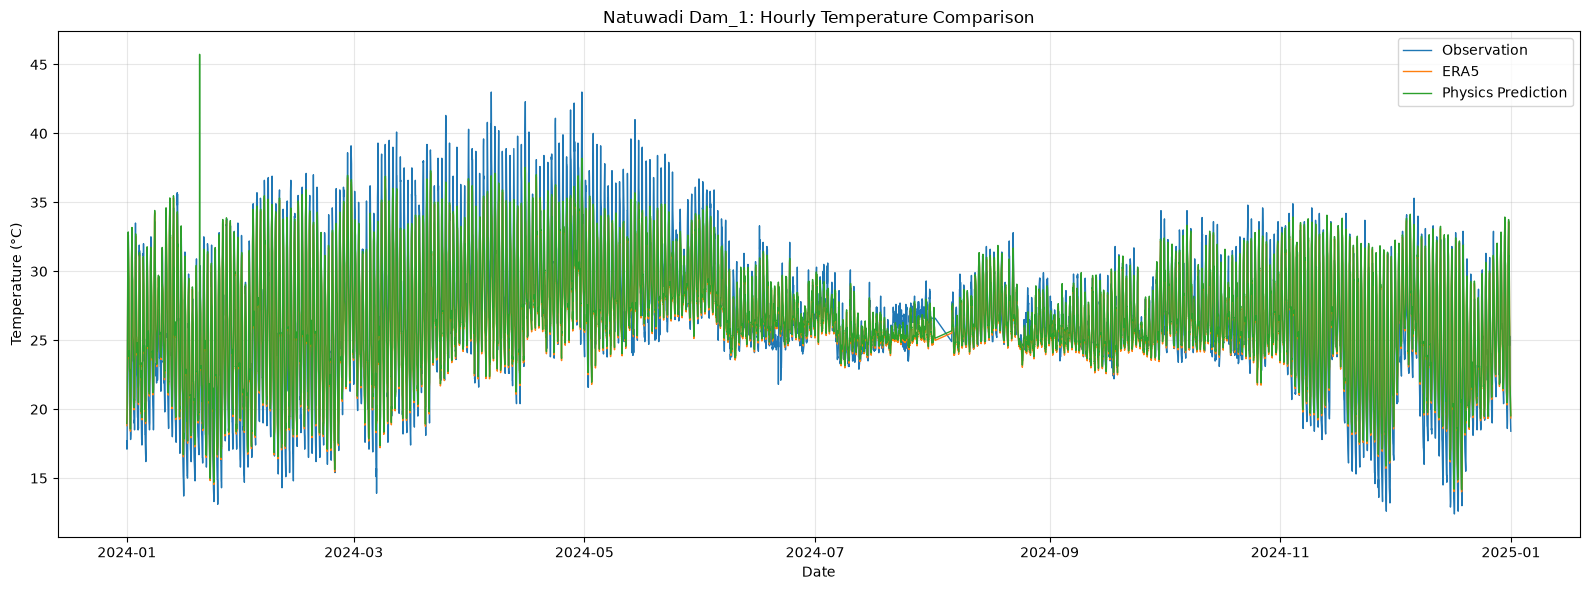

In [89]:
import matplotlib.pyplot as plt

stations = [
    "Aurangpur",
    "Bhatsanagar_1",
    "Natuwadi Dam_1"
]

for station in stations:

    plot_df = validation_clean[
        validation_clean["Station"] == station
    ].sort_values("time_utc")

    plt.figure(figsize=(16, 6))

    plt.plot(
        plot_df["time_utc"],
        plot_df["observed_temperature_C"],
        label="Observation",
        linewidth=1
    )

    plt.plot(
        plot_df["time_utc"],
        plot_df["temperature_C"],
        label="ERA5",
        linewidth=1
    )

    plt.plot(
        plot_df["time_utc"],
        plot_df["physics_prediction_C"],
        label="Physics Prediction",
        linewidth=1
    )

    plt.title(
        f"{station}: Hourly Temperature Comparison"
    )

    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()